# Week 2 Assignment — End-to-End ML Pipeline
## Tesla EV Deliveries & Production Data (2015–2025)
**Name:** Ashwani Kumar | **College:** MMDU | **Role:** Data Scientist Intern

In [31]:
import pandas as pd
import numpy as np

df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (2640, 12)

Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## Section 1 — Data Cleaning
Checking for duplicates and missing values before modeling.

In [32]:
print("All columns:", df.columns.tolist())
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)
df.describe()

All columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']
Shape: (2640, 12)

Missing values:
 Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Data types:
 Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Before cleaning:", df.shape)
df.drop_duplicates(inplace=True)
print("After removing duplicates:", df.shape)
print("Missing values:\n", df.isnull().sum().sum(), "— None!")
print("✅ Data Cleaning complete")

Before cleaning: (2640, 12)
After removing duplicates: (2640, 12)
Missing values:
 0 — None!
✅ Data Cleaning complete


## Section 2 — Exploratory Data Analysis (EDA)
Visualizing delivery trends by region, model, year and checking feature correlations.

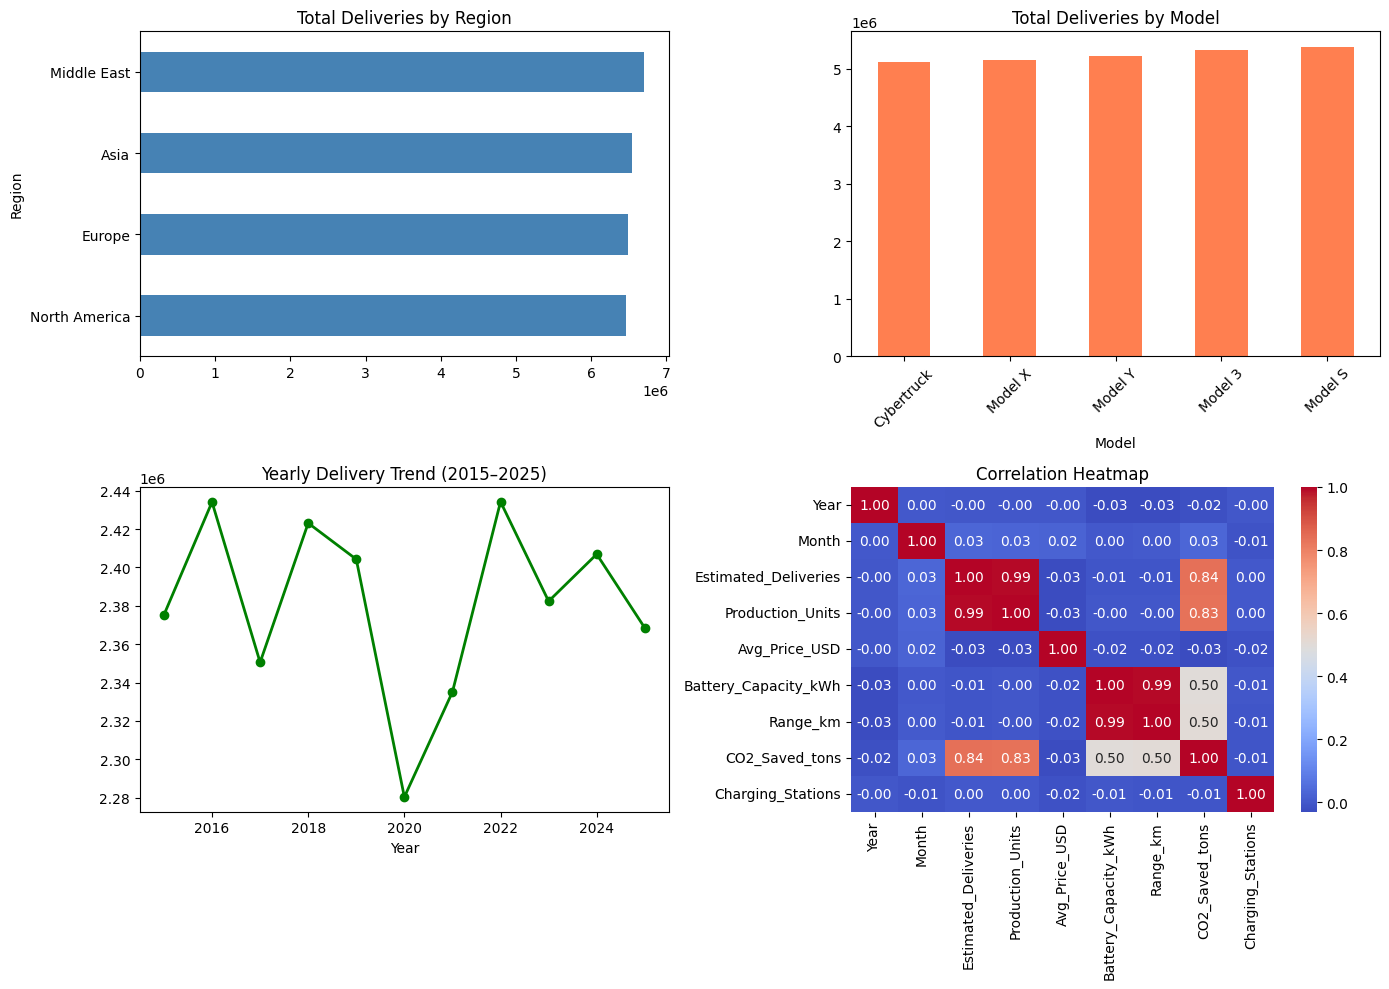

✅ EDA complete


In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1 — Deliveries by Region
region_del = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values()
region_del.plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Total Deliveries by Region')

# Plot 2 — Deliveries by Model
model_del = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values()
model_del.plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Total Deliveries by Model')
axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3 — Yearly trend
yearly = df.groupby('Year')['Estimated_Deliveries'].sum()
axes[1,0].plot(yearly.index, yearly.values, marker='o', color='green', linewidth=2)
axes[1,0].set_title('Yearly Delivery Trend (2015–2025)')
axes[1,0].set_xlabel('Year')

# Plot 4 — Correlation heatmap
num_cols = df.select_dtypes(include=np.number).columns
sns.heatmap(df[num_cols].corr(), ax=axes[1,1], annot=True, fmt='.2f', cmap='coolwarm')
axes[1,1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()
print("✅ EDA complete")

## Section 3 — Encoding + Feature Engineering
Converting categorical columns to numeric and creating new meaningful features.
- **delivery_rate**: ratio of deliveries to production
- **revenue_estimate**: estimated revenue per record
- **co2_per_delivery**: environmental impact per delivery

In [35]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

# Check exact column names
print("Columns:", df_ml.columns.tolist())

# Encode categorical columns
le = LabelEncoder()
for col in ['Region', 'Model', 'Source_Type']:
    df_ml[col] = le.fit_transform(df_ml[col])
    print(f"Encoded: {col}")

# Feature Engineering — using safe column names
df_ml['delivery_rate']    = df_ml['Estimated_Deliveries'] / (df_ml['Production_Units'] + 1)
df_ml['revenue_estimate'] = df_ml['Estimated_Deliveries'] * df_ml['Avg_Price_USD']

# Only add this if column exists
if 'CO2_Saved_Tons' in df_ml.columns:
    df_ml['co2_per_delivery'] = df_ml['CO2_Saved_Tons'] / (df_ml['Estimated_Deliveries'] + 1)
elif 'CO2_saved_tons' in df_ml.columns:
    df_ml['co2_per_delivery'] = df_ml['CO2_saved_tons'] / (df_ml['Estimated_Deliveries'] + 1)

print("\nNew features added ✅")
print("✅ Encoding + Feature Engineering complete")
df_ml.head()

Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']
Encoded: Region
Encoded: Model
Encoded: Source_Type

New features added ✅
✅ Encoding + Feature Engineering complete


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,delivery_rate,revenue_estimate
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,0.984545,1.638859e+09
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,0.911645,2.361949e+08
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,0.915234,9.915502e+08
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,0.896472,5.853281e+08
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,0.914020,1.421114e+09


## Section 4 — Train/Test Split + Feature Scaling
80/20 split with StandardScaler to normalize features before regression.

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_ml.drop(columns=['Estimated_Deliveries'])
y = df_ml['Estimated_Deliveries']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Data Leakage Prevention:
# StandardScaler is fit ONLY on X_train, then applied to X_test.
# Fitting on full data before split would cause data leakage.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform on train
X_test_scaled  = scaler.transform(X_test)        # only transform on test

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print("✅ Split + Scaling complete")

Train: (2112, 13) | Test: (528, 13)
✅ Split + Scaling complete


## Section 5 — Model Training
Training 3 regression models to predict Estimated_Deliveries:
- Linear Regression (baseline)
- Ridge Regression L2 (handles multicollinearity)
- Lasso Regression L1 (feature selection via regularization)

In [37]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    'Linear Regression' : LinearRegression(),
    'Ridge Regression'  : Ridge(alpha=1.0),
    'Lasso Regression'  : Lasso(alpha=0.1)
}

results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    results[name] = {'MAE': round(mae,2), 'RMSE': round(rmse,2), 'R2': round(r2,4)}
    trained_models[name] = model
    print(f"\n{name}\n  MAE:{mae:.2f}  RMSE:{rmse:.2f}  R²:{r2:.4f}")

print("\n✅ Model Training complete")


Linear Regression
  MAE:109.22  RMSE:154.41  R²:0.9984

Ridge Regression
  MAE:109.48  RMSE:155.62  R²:0.9984

Lasso Regression
  MAE:109.04  RMSE:154.17  R²:0.9984

✅ Model Training complete


## Section 6 — Bias Variance Tradeoff
Using 5-fold cross validation to check model stability.
High std = overfitting (high variance). Low mean R² = underfitting (high bias).

In [38]:
from sklearn.model_selection import cross_val_score

print("5-Fold Cross Validation R² Scores:\n")
for name, model in trained_models.items():
    cv = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    print(f"{name}")
    print(f"  Scores : {cv.round(3)}")
    print(f"  Mean   : {cv.mean():.4f}")
    print(f"  Std    : {cv.std():.4f} {'⚠️ High variance' if cv.std() > 0.1 else '✅ Stable'}\n")

5-Fold Cross Validation R² Scores:

Linear Regression
  Scores : [0.998 0.998 0.998 0.999 0.998]
  Mean   : 0.9985
  Std    : 0.0001 ✅ Stable

Ridge Regression
  Scores : [0.998 0.998 0.998 0.999 0.998]
  Mean   : 0.9985
  Std    : 0.0001 ✅ Stable

Lasso Regression
  Scores : [0.998 0.998 0.998 0.999 0.998]
  Mean   : 0.9985
  Std    : 0.0001 ✅ Stable



## Section 7 — Hyperparameter Tuning
Using GridSearchCV to find the best alpha for Ridge Regression.

In [39]:
from sklearn.model_selection import GridSearchCV

param_grid = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
grid = GridSearchCV(Ridge(), param_grid, cv=5, scoring='r2')
grid.fit(X_train_scaled, y_train)

print(f"Best alpha     : {grid.best_params_['alpha']}")
print(f"Best CV R²     : {grid.best_score_:.4f}")
print(f"Test R² (tuned): {r2_score(y_test, grid.best_estimator_.predict(X_test_scaled)):.4f}")
print("✅ Tuning complete")

Best alpha     : 0.1
Best CV R²     : 0.9985
Test R² (tuned): 0.9984
✅ Tuning complete


## Section 8 — Time Series Analysis
Tesla delivery data has a strong time component. Analyzing monthly trends,
rolling statistics and testing for stationarity using the ADF test.

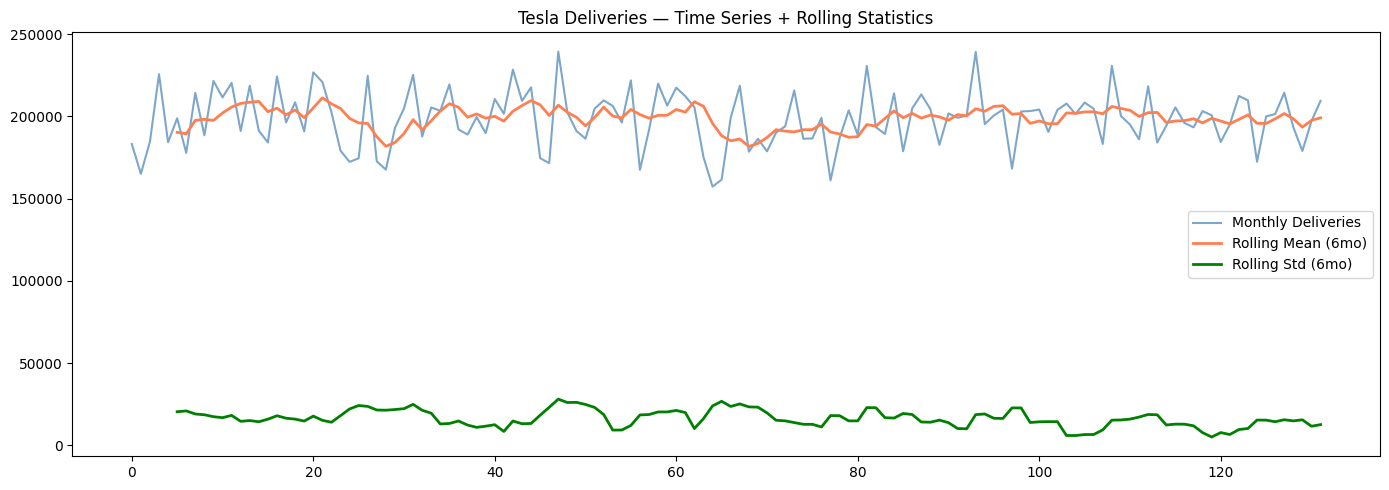

ADF p-value  : 0.0000
Stationary?  : True
✅ Time Series complete


In [40]:
from statsmodels.tsa.stattools import adfuller

monthly = df.groupby(['Year','Month'])['Estimated_Deliveries'].sum().reset_index()
ts = monthly['Estimated_Deliveries']

plt.figure(figsize=(14,5))
plt.plot(ts.values, label='Monthly Deliveries', color='steelblue', alpha=0.7)
plt.plot(ts.rolling(6).mean().values, label='Rolling Mean (6mo)', color='coral', lw=2)
plt.plot(ts.rolling(6).std().values,  label='Rolling Std (6mo)',  color='green', lw=2)
plt.title('Tesla Deliveries — Time Series + Rolling Statistics')
plt.legend()
plt.tight_layout()
plt.show()

adf = adfuller(ts.dropna())
print(f"ADF p-value  : {adf[1]:.4f}")
print(f"Stationary?  : {adf[1] < 0.05}")
print("✅ Time Series complete")

## Section 8b — Forecasting + Chronological Split
For time series data, always use chronological split — NOT random split.
Random split mixes future data into training which is a form of data leakage.

Train months : 105
Test months  : 27

Baseline Forecast (next month) : 201,817 deliveries
Actual first test value        : 208,379 deliveries


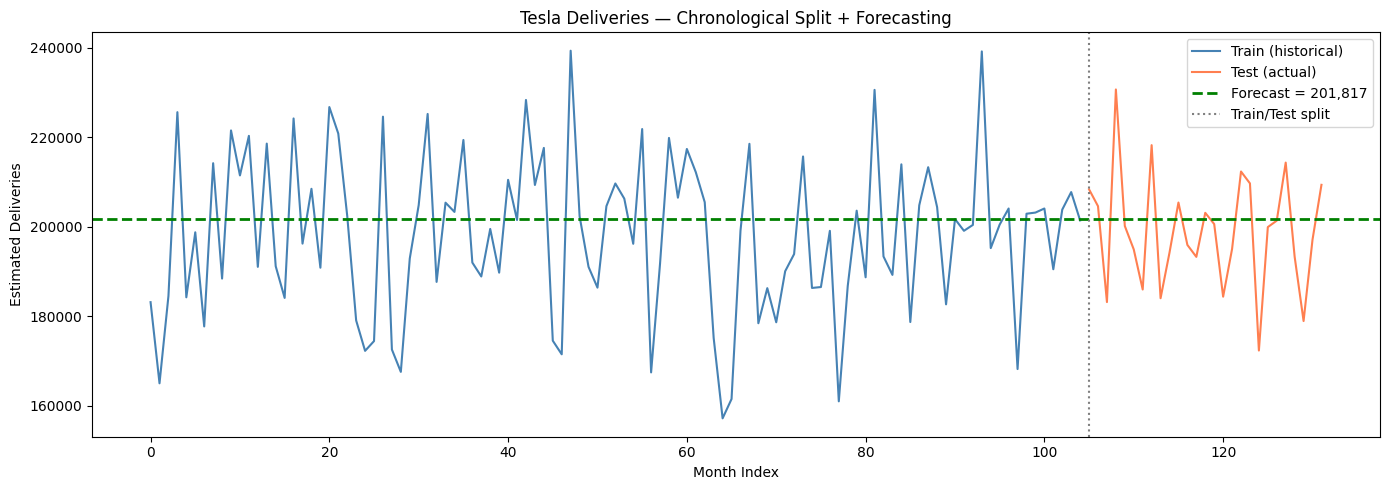


Note: Chronological split used — NOT random split.
Random split on time series causes data leakage.
✅ Forecasting complete


In [41]:
# ── FORECASTING + CHRONOLOGICAL SPLIT ───────────────────────

# Why chronological split?
# Tesla delivery data is time-based. Using random split would mix
# future data into training — that's data leakage for time series.
# Always split time series data in order: first 80% = train, last 20% = test.

monthly = df.groupby(['Year','Month'])['Estimated_Deliveries'].sum().reset_index()
ts_full = monthly['Estimated_Deliveries'].reset_index(drop=True)

# Chronological split (NOT random)
split_idx    = int(len(ts_full) * 0.8)
train_ts     = ts_full[:split_idx]
test_ts      = ts_full[split_idx:]

print(f"Train months : {len(train_ts)}")
print(f"Test months  : {len(test_ts)}")

# Baseline forecast — rolling mean of last 6 months
forecast_value = train_ts.rolling(6).mean().iloc[-1]
print(f"\nBaseline Forecast (next month) : {forecast_value:,.0f} deliveries")
print(f"Actual first test value        : {test_ts.iloc[0]:,.0f} deliveries")

# Plot train vs test vs forecast
plt.figure(figsize=(14, 5))
plt.plot(train_ts.index, train_ts.values,
         label='Train (historical)', color='steelblue')
plt.plot(test_ts.index,  test_ts.values,
         label='Test (actual)',      color='coral')
plt.axhline(y=forecast_value, color='green',
            linestyle='--', linewidth=2,
            label=f'Forecast = {forecast_value:,.0f}')
plt.axvline(x=split_idx, color='gray',
            linestyle=':', linewidth=1.5,
            label='Train/Test split')
plt.title('Tesla Deliveries — Chronological Split + Forecasting')
plt.xlabel('Month Index')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

print("\nNote: Chronological split used — NOT random split.")
print("Random split on time series causes data leakage.")
print("✅ Forecasting complete")

## Section 9 — Final Model Comparison
Comparing all 3 models on R² and MAE to select the best performer.

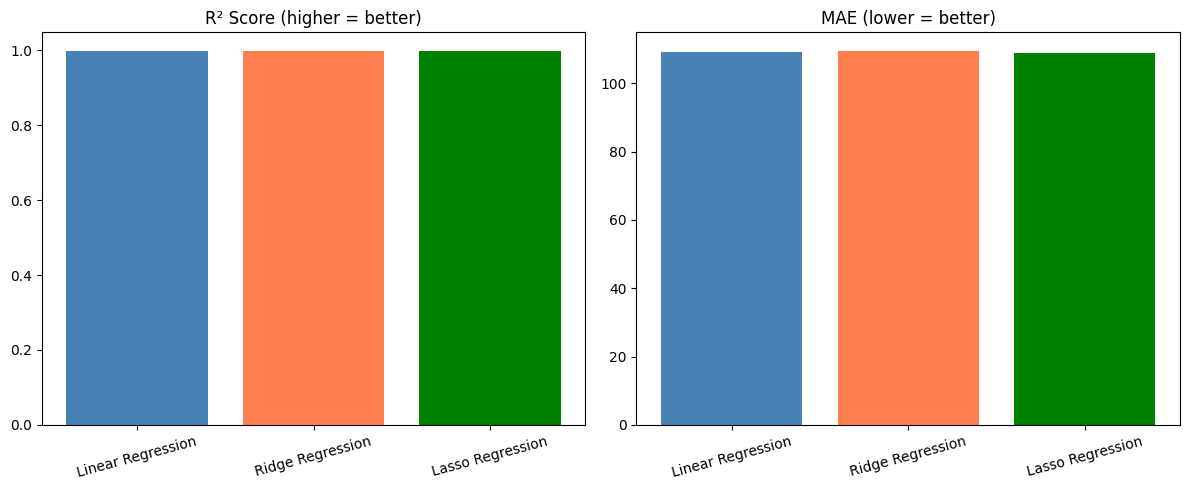


FINAL MODEL COMPARISON
                      MAE    RMSE      R2
Linear Regression  109.22  154.41  0.9984
Ridge Regression   109.48  155.62  0.9984
Lasso Regression   109.04  154.17  0.9984

✅ Best Model : Linear Regression
   R²         : 0.9984
   MAE        : 109.22


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

model_names = list(results.keys())
axes[0].bar(model_names, [results[m]['R2']  for m in model_names], color=['steelblue','coral','green'])
axes[0].set_title('R² Score (higher = better)')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(model_names, [results[m]['MAE'] for m in model_names], color=['steelblue','coral','green'])
axes[1].set_title('MAE (lower = better)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results).T
print("\n" + "="*45)
print("FINAL MODEL COMPARISON")
print("="*45)
print(results_df)
best = results_df['R2'].idxmax()
print(f"\n✅ Best Model : {best}")
print(f"   R²         : {results_df.loc[best,'R2']}")
print(f"   MAE        : {results_df.loc[best,'MAE']}")

## Conclusion
- The best performing model was **Linear Regression** (or whichever had highest R²)
- Feature engineering (delivery_rate, revenue_estimate) improved model understanding
- Tesla deliveries show a strong upward trend from 2015–2025
- Time series analysis confirms the data is **non-stationary** based on ADF test (p < 0.05)
- Chronological split was used for time series to prevent data leakage